# Imports

In [1]:
import sys
import imp
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import spearmanr,pearsonr,ttest_1samp, ttest_ind
import pickle
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
sys.path.append('../data_processing_code/')
sys.path.append('.')

import get_data
imp.reload(get_data)
from get_data import get_data, get_data_online

import plotting
imp.reload(plotting)
from plotting import *


In [3]:
def scale_fun(X, axis=0, with_mean=True, with_std=True, copy=True):
    X = X.copy()
    X = np.asarray(X)

    if with_mean:
        mean_ = np.nanmean(X, axis)
    if with_std:
        scale_ = np.nanstd(X, axis)
    # Xr is a view on the original array that enables easy use of
    # broadcasting on the axis in which we are interested in
    Xr = np.rollaxis(X, axis)
    if with_mean:
        Xr -= mean_
        mean_1 = np.nanmean(Xr, axis=0)
        # Verify that mean_1 is 'close to zero'. If X contains very
        # large values, mean_1 can also be very large, due to a lack of
        # precision of mean_. In this case, a pre-scaling of the
        # concerned feature is efficient, for instance by its mean or
        # maximum.
        if not np.allclose(mean_1, 0):
            warnings.warn("Numerical issues were encountered "
                          "when centering the data "
                          "and might not be solved. Dataset may "
                          "contain too large values. You may need "
                          "to prescale your features.")
            Xr -= mean_1
    if with_std:
        scale_ = scale_ #_handle_zeros_in_scale(scale_, copy=False)
        Xr /= scale_
        if with_mean:
            mean_2 = np.nanmean(Xr, axis=0)
            # If mean_2 is not 'close to zero', it comes from the fact that
            # scale_ is very small so that mean_2 = mean_1/scale_ > 0, even
            # if mean_1 was close to zero. The problem is thus essentially
            # due to the lack of precision of mean_. A solution is then to
            # subtract the mean again:
            if not np.allclose(mean_2, 0):
                warnings.warn("Numerical issues were encountered "
                              "when scaling the data "
                              "and might not be solved. The standard "
                              "deviation of the data is probably "
                              "very close to 0. ")
                Xr -= mean_2
    return X

In [4]:
def convert_diagnosis_to_color(diag):
    color=[]
    for d in diag:
        if d=='control_mfmri':
            color.append(sns.color_palette()[0])
        elif d=='control_cdm':
            color.append(sns.color_palette()[1])
        elif d=='MDD':
            color.append(sns.color_palette()[2])
        elif d=='GAD':
            color.append(sns.color_palette()[6])
        elif d=='amt':
            color.append(sns.color_palette()[4])
    return(color)

# Load Shared Data

## Load Data

In [5]:
dftmp = pd.read_csv('../data/participant_table_exp1.csv')
data = get_data(dftmp)

pain task excluded:12
rew task excluded:9
has both: 71
pain only:6
rew only:9
subj X task:157
subjs:86
(180, 157)
(180, 157)
(180, 157)
(180, 157)


## Load Online Data

In [6]:
dftmp = pd.read_csv('../data/participant_table_exp2.csv')
data_online = get_data_online(dftmp)

subj X task:294
subjs:147
(180, 294)
(180, 294)
(180, 294)
(180, 294)


# Specs

In [7]:
plt.rcParams.update({'font.size': 11})
plt.rcParams.update({'font.family': 'normal'})

# x,y label size
labelsize =10
ticklabelsize=8
legendsize=8

# Appendix 5 

In [8]:
data = data
go_rew_stab = []
go_rew_vol = []
go_pain_stab = []
go_pain_vol = []

omr_rew_stab = []
omr_rew_vol = []
omr_pain_stab = []
omr_pain_vol = []

Bi1_rew = []
Bi1_pain = []
for subj in range(data['good_outcomes_del_bin'].shape[1]):
    go = data['good_outcomes_del_bin'][:,subj]
    rewpain = data['rewpain'][:,subj]
    stabvol = data['stabvol'][:,subj]
    m1 = data['mag_1_c'][:,subj]
    m0 = data['mag_0_c'][:,subj]
    choices = data['participants_choice'][:,subj]
    outcomes = data['outcomes_c_flipped'][:,subj]
    out_mag_rec = m1*((choices==1)&(outcomes==1)).astype('int')+m0*((choices==0)&(outcomes==0)).astype('int')
    out_mag_rec = out_mag_rec*100
    if rewpain[0]==1:
        go_rew_stab.append(np.mean(go[stabvol==1]))
        go_rew_vol.append(np.mean(go[stabvol==-1]))
        omr_rew_stab.append(np.mean(out_mag_rec[stabvol==1]))
        omr_rew_vol.append(np.mean(out_mag_rec[stabvol==-1]))
        Bi1_rew.append(data['Bi1item_w_j_scaled'][subj])
    elif rewpain[0]==-1:
        go_pain_stab.append(np.mean(go[stabvol==1]))
        go_pain_vol.append(np.mean(go[stabvol==-1]))  
        omr_pain_stab.append(-1*np.mean(out_mag_rec[stabvol==1]))
        omr_pain_vol.append(-1*np.mean(out_mag_rec[stabvol==-1]))
        Bi1_pain.append(data['Bi1item_w_j_scaled'][subj])

In [9]:
go_rew_stab_online = []
go_rew_vol_online = []
go_pain_stab_online = []
go_pain_vol_online = []

omr_rew_stab_online = []
omr_rew_vol_online = []
omr_pain_stab_online = []
omr_pain_vol_online = []

Bi1_rew_online = []
Bi1_pain_online = []
for subj in range(data_online['good_outcomes_del_bin'].shape[1]):
    go = data_online['good_outcomes_del_bin'][:,subj]
    rewpain = data_online['rewpain'][:,subj]
    stabvol = data_online['stabvol'][:,subj]
    m1 = data_online['mag_1_c'][:,subj]
    m0 = data_online['mag_0_c'][:,subj]
    choices = data_online['participants_choice'][:,subj]
    outcomes = data_online['outcomes_c_flipped'][:,subj]
    out_mag_rec = m1*((choices==1)&(outcomes==1)).astype('int')+m0*((choices==0)&(outcomes==0)).astype('int')
    out_mag_rec = out_mag_rec*100
    if rewpain[0]==1:
        go_rew_stab_online.append(np.mean(go[stabvol==1]))
        go_rew_vol_online.append(np.mean(go[stabvol==-1]))
        omr_rew_stab_online.append(np.mean(out_mag_rec[stabvol==1]))
        omr_rew_vol_online.append(np.mean(out_mag_rec[stabvol==-1]))
        Bi1_rew_online.append(np.hstack((data_online['Bi1item_w_j_scaled_both'],
                                         data_online['Bi1item_w_j_scaled_both']))[subj])
    elif rewpain[0]==-1:
        go_pain_stab_online.append(np.mean(go[stabvol==1]))
        go_pain_vol_online.append(np.mean(go[stabvol==-1]))  
        omr_pain_stab_online.append(-1*np.mean(out_mag_rec[stabvol==1]))
        omr_pain_vol_online.append(-1*np.mean(out_mag_rec[stabvol==-1]))
        Bi1_pain_online.append(np.hstack((data_online['Bi1item_w_j_scaled_both'],
                                          data_online['Bi1item_w_j_scaled_both']))[subj])
    

findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.
findfont: Font family ['normal'] not found. Falling back to DejaVu Sans.


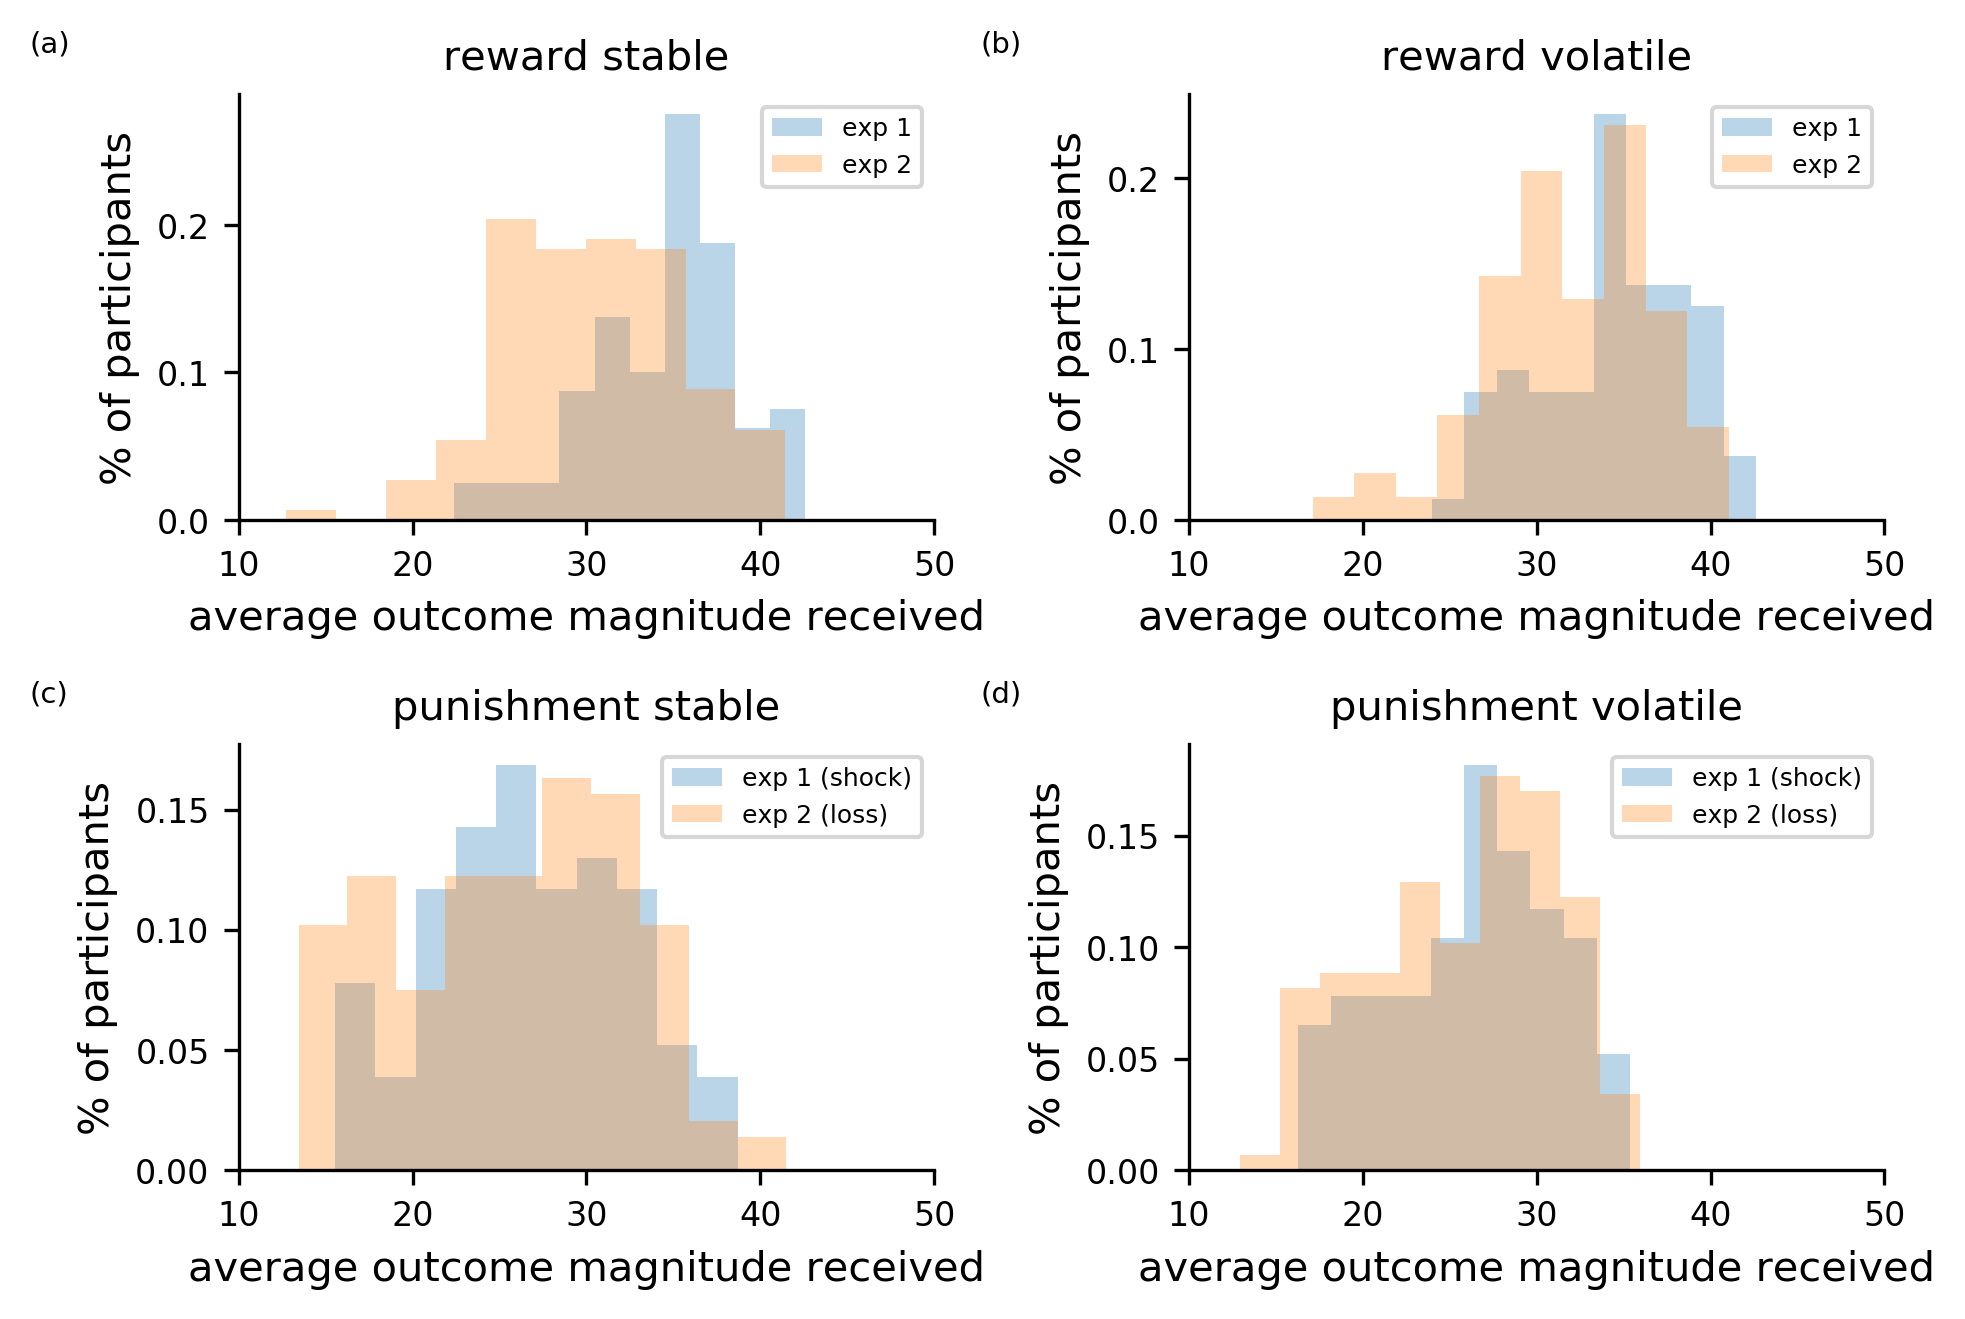

In [10]:
plt.figure(figsize=(6.5,4.5),dpi=300)
labelsize =10
ticklabelsize=8
legendsize=8
annotsize=4
s=5
linewidth=1

#bins = [25,30,35,40,45,50]
titles = ['reward stable','reward volatile','punishment stable','punishment volatile']
for i,(go,go_online) in enumerate(zip([omr_rew_stab,omr_rew_vol,omr_pain_stab,omr_pain_vol],
                         [omr_rew_stab_online,omr_rew_vol_online,omr_pain_stab_online,omr_pain_vol_online])):
    go = np.array(go)
    go_online = np.array(go_online)
    plt.subplot(2,2,i+1)
    title = titles[i]
    
    weights = np.ones_like(go)/float(len(go))
    if 'punish' in title:
        label1='exp 1 (shock)'
    else:
        label1='exp 1'
    plt.hist(go,weights=weights,alpha=0.3,label=label1)
                                
    weights = np.ones_like(go_online)/float(len(go_online))
    if 'punish' in title:
        label2='exp 2 (loss)'
    else:
        label2='exp 2'
    plt.hist(go_online,weights=weights,alpha=0.3,label=label2)
    
    #plt.axvline(x = 27.5)
                                
    plt.title(title,fontsize=labelsize)

    plt.xlabel('average outcome magnitude received',fontsize=labelsize)
    plt.ylabel('% of participants',fontsize=labelsize)
    plt.xlim([10,50])
    #plt.ylim([0,0.4])
    sns.despine()
    plt.legend(fontsize=legendsize-2)
    plt.xticks(fontsize=ticklabelsize)
    plt.yticks(fontsize=ticklabelsize)
    plt.tight_layout()

# panel labels 
axes = plt.gcf().get_axes()
for ax,lab in zip(axes,['(a)','(b)','(c)','(d)']):
    ax.text(-0.3,1.1,lab,fontsize=7,transform=ax.transAxes)


plt.savefig('../figures/appendix5_figure1.png',bbox_inches='tight',dpi=500)
